In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import json
import numpy as np
import math
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.svm import SVC 
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import LSTM, Dense, Dropout # type: ignore
from tensorflow.keras.utils import to_categorical # type: ignore
from keras.models import Sequential
from sklearn.decomposition import PCA
from keras.layers import  Convolution3D,Convolution2D, MaxPooling3D,MaxPooling2D, Flatten, Dropout, Dense

from tensorflow.keras.optimizers import Adam


In [2]:
input_files = [
    "bent-over_rows",
    "biceps",
    "latheral_raises",
    "rdl",
    "shoulder_press",
    "squat"
]


In [3]:
def calculateFrameVectors(json_file, frame_idx):
    frame1 = json_file['frames'][frame_idx]
    frame2 = json_file['frames'][frame_idx+1]

    #a két kép közötti kulcspontokból csinál vektorokat
    frameDatas=[]

    for i in range(len(frame1['keypoints'])):
        vector=[]
        # vector.append(frame1['keypoints'][i]['x'])
        # vector.append(frame1['keypoints'][i]['y'])
        

        vector.append(frame2['keypoints'][i]['x']- frame1['keypoints'][i]['x'])
        vector.append(frame2['keypoints'][i]['y']- frame1['keypoints'][i]['y'])
        # vector.append(frame2['keypoints'][i]['depth']- frame1['keypoints'][i]['depth'])
        
        frameDatas.append(vector)
    return frameDatas


In [8]:
base_path = r"C:\Users\Legion\Documents\Projektmunka\DepthBasics-WPF\bin\Debug\frames"
data= []
Y_train=[]

X_test=[]
Y_test=[]

for file_name in input_files:  # Fájlnév iteráció
    file_folder_path = os.path.join(base_path, file_name)

    contents= os.listdir(file_folder_path)

    trainingSize=0.2*len(contents)


    for i in range(len(contents)): 


        file_path = os.path.join(file_folder_path, contents[i])

        with open(file_path, "r") as f:
            

            json_file=json.load(f)
            movement=[]


            for frame_idx in range(len(json_file['frames'])-1): 
                frameDatas=calculateFrameVectors(json_file, frame_idx)
                movement.append(frameDatas)
                if(len(movement)==25):  
                    if i<trainingSize :
                        X_test.append(movement)  
                        Y_test.append(json_file['video_name'])
                        movement=[]
                    else :
                        data.append(movement)
                        Y_train.append(json_file['video_name'])
                        movement=[]

X_train= np.array(data)
Y_train= np.array(Y_train)
X_test= np.array(X_test)
Y_test = np.array(Y_test)


print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test .shape)

(217, 25, 25, 2)
(217,)
(67, 25, 25, 2)
(67,)


In [58]:
# indices = np.arange(data_array.shape[0])  # [0, 1, ..., 567]
# np.random.shuffle(indices)

# # Train-test split (80-20 arány)
# train_size = int(0.8 * len(indices))  # 80% a teljes mintából
# train_indices = indices[:train_size]
# test_indices = indices[train_size:]

# # Adatok szétválasztása az indexek alapján
# X_train = data[train_indices]
# X_test = data[test_indices]


In [9]:

# X_train = data_array[indices_train]
# X_test= data_array[indices_test]

# test_indices = indices[train_size:]
encoder=LabelEncoder()
Y_test= encoder.fit_transform(Y_test)
Y_train= encoder.fit_transform(Y_train)

Y_test= to_categorical(Y_test)
Y_train= to_categorical(Y_train)



In [10]:
print(Y_train.shape)

(217, 6)


In [13]:
model= Sequential()
model.add(Convolution2D(filters=16, kernel_size=(3,3),activation='relu', input_shape=(25, 25, 2)))
model.add(MaxPooling2D((2,2)))
model.add(Convolution2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(6, activation='softmax'))


model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])

history= model.fit(X_train, Y_train,validation_data=(X_test, Y_test), epochs=50, batch_size=2)

Epoch 1/50
109/109 [==============================] - 2s 6ms/step - loss: 15.4015 - accuracy: 0.2120 - val_loss: 3.2343 - val_accuracy: 0.2239
Epoch 2/50
109/109 [==============================] - 0s 4ms/step - loss: 3.2880 - accuracy: 0.3641 - val_loss: 3.6409 - val_accuracy: 0.3881
Epoch 3/50
109/109 [==============================] - 0s 4ms/step - loss: 2.2028 - accuracy: 0.4793 - val_loss: 2.6879 - val_accuracy: 0.3433
Epoch 4/50
109/109 [==============================] - 0s 4ms/step - loss: 1.3136 - accuracy: 0.6359 - val_loss: 2.1952 - val_accuracy: 0.4179
Epoch 5/50
109/109 [==============================] - 0s 4ms/step - loss: 1.0458 - accuracy: 0.6866 - val_loss: 2.5018 - val_accuracy: 0.5373
Epoch 6/50
109/109 [==============================] - 0s 4ms/step - loss: 0.9605 - accuracy: 0.7373 - val_loss: 2.4394 - val_accuracy: 0.5224
Epoch 7/50
109/109 [==============================] - 0s 4ms/step - loss: 0.6057 - accuracy: 0.8387 - val_loss: 2.6141 - val_accuracy: 0.5970
Epoch

In [14]:
y_pred= model.predict(X_test)

3/3 [==============================] - 0s 0s/step


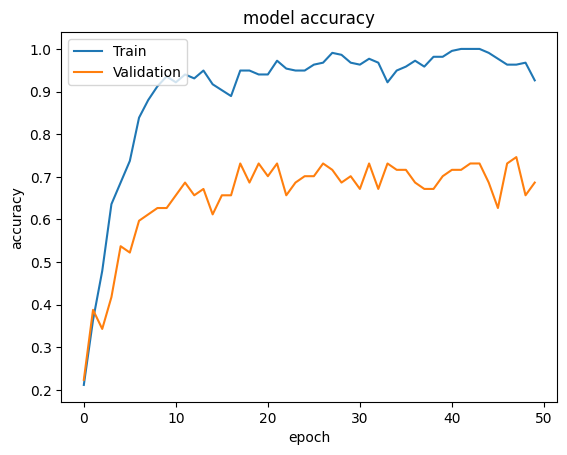

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [16]:
y_pred_classes = np.argmax(y_pred, axis=1)  # Prediktált osztályok
y_true_classes = np.argmax(Y_test, axis=1)

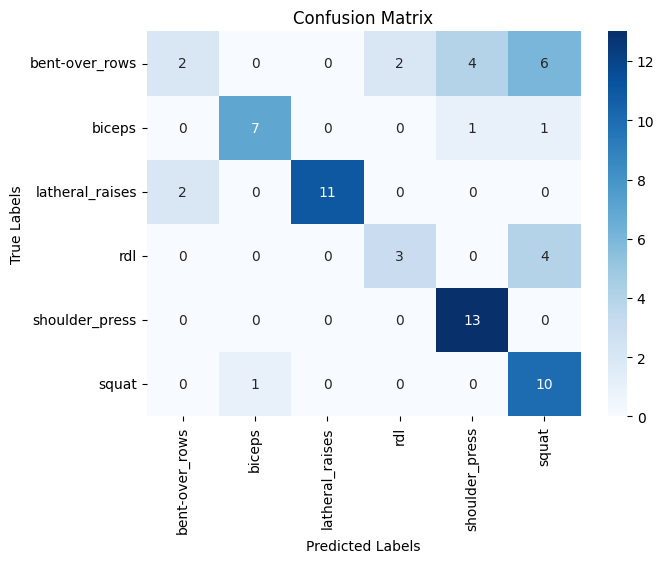

In [17]:
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Opció: Normálás (százalékos értékekhez)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
corr_labels= input_files
# Kirajzolás Seaborn segítségével
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=corr_labels, yticklabels=corr_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [22]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 23, 23, 16)        304       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 11, 11, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 9, 9, 32)          4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 4, 4, 32)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 512)               0         
                                                                 
 dense (Dense)               (None, 256)               1

In [23]:
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)  # verbose=0 nem ír ki részleteket


In [24]:
print(loss)
print(accuracy)

5.665087699890137
0.6865671873092651
